# Employee Attrition Prediction using Machine Learning

## Internship Project – Week 2

**Intern:** Mishty Giri

**Project Duration:** 23 June 2026 – 30 June 2026

---

## Project Objective

Employee attrition is a major concern for organizations because replacing experienced employees is costly and time-consuming. This project aims to build a Machine Learning model that predicts whether an employee is likely to leave the company based on demographic, job-related, and workplace factors.

The project involves data exploration, preprocessing, exploratory data analysis (EDA), model development, evaluation, and business recommendations. The final goal is to provide actionable insights that can help Human Resource (HR) departments identify employees at risk of leaving and implement effective retention strategies.

In [1]:

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
df = pd.read_csv("HR_Attrition.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
# Display the first 10 records
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
# Number of rows and columns
rows, columns = df.shape
print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")

Number of Rows    : 1470
Number of Columns : 35


In [5]:
# Display column names, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [7]:
# Check duplicate records
duplicates = df.duplicated().sum()
print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


In [8]:
# Display all column names
print("Columns in the dataset:\n")

for column in df.columns:
    print(column)

Columns in the dataset:

Age
Attrition
BusinessTravel
DailyRate
Department
DistanceFromHome
Education
EducationField
EmployeeCount
EmployeeNumber
EnvironmentSatisfaction
Gender
HourlyRate
JobInvolvement
JobLevel
JobRole
JobSatisfaction
MaritalStatus
MonthlyIncome
MonthlyRate
NumCompaniesWorked
Over18
OverTime
PercentSalaryHike
PerformanceRating
RelationshipSatisfaction
StandardHours
StockOptionLevel
TotalWorkingYears
TrainingTimesLastYear
WorkLifeBalance
YearsAtCompany
YearsInCurrentRole
YearsSinceLastPromotion
YearsWithCurrManager


### Observation

The dataset contains employee demographic information, job-related attributes, compensation details, and the target variable **Attrition**, which indicates whether an employee has left the organization.

In [9]:
# Target Variable
print("Target Column:", "Attrition")

Target Column: Attrition


### Observation

The target variable is **Attrition**, which contains two categories:
- Yes → Employee left the company
- No → Employee stayed with the company

This is a binary classification problem.

In [10]:
# Count employees who stayed vs left
attrition_counts = df['Attrition'].value_counts()

print(attrition_counts)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [11]:
# Calculate Attrition Rate

attrition_rate = df['Attrition'].value_counts(normalize=True) * 100

print(attrition_rate.round(2))

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


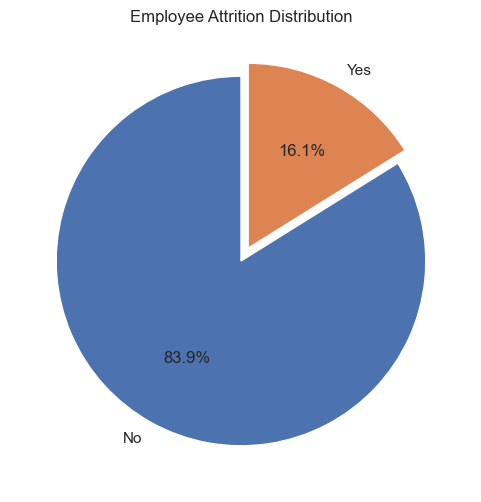

In [12]:
plt.figure(figsize=(6,6))

plt.pie(
    attrition_counts,
    labels=attrition_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0,0.08]
)

plt.title("Employee Attrition Distribution")

plt.show()

### Observation

Approximately **84%** of employees stayed with the company, while only about **16%** left.

This indicates that the dataset is **imbalanced**, meaning there are significantly fewer examples of employees who left compared to those who stayed. This imbalance should be considered during model training.

In [13]:
# Identify Numerical and Categorical Features

numerical_columns = df.select_dtypes(include=['int64','float64']).columns

categorical_columns = df.select_dtypes(include=['object']).columns

print(f"Number of Numerical Columns : {len(numerical_columns)}")

print(f"Number of Categorical Columns : {len(categorical_columns)}")

Number of Numerical Columns : 26
Number of Categorical Columns : 9


In [14]:
print("\nNumerical Columns:\n")

print(list(numerical_columns))

print("\nCategorical Columns:\n")

print(list(categorical_columns))


Numerical Columns:

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Columns:

['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


### Observation

The dataset contains both numerical and categorical features.

Numerical variables include age, income, years at company, and performance-related measures, while categorical variables include department, job role, business travel, marital status, and education field.

These categorical variables will need to be encoded before training machine learning models.

In [15]:
# Check Missing Values

missing_values = df.isnull().sum()

missing_values

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [16]:
missing_values[missing_values > 0]

Series([], dtype: int64)

### Observation

No missing values were found in the dataset.

Since the dataset is complete, no imputation or missing value treatment is required before model training.

In [17]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [18]:
unique_values = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": df.nunique().values
})

unique_values

,Column,Unique Values
0,Age,43
1,Attrition,2
2,BusinessTravel,3
3,DailyRate,886
4,Department,3
5,DistanceFromHome,29
6,Education,5
7,EducationField,6
8,EmployeeCount,1
9,EmployeeNumber,1470


## Summary of Data Exploration

- The dataset contains **1,470 employee records** and **35 features**.
- The target variable **Attrition** is binary, indicating whether an employee stayed or left the company.
- Approximately **16%** of employees left the organization, indicating an imbalanced dataset.
- No missing values were detected, simplifying the preprocessing stage.
- The dataset includes a mix of numerical and categorical variables that will require preprocessing before model development.

In [19]:
# Remove unnecessary columns

df.drop(
    columns=[
        'EmployeeCount',
        'EmployeeNumber',
        'Over18',
        'StandardHours'
    ],
    inplace=True
)

In [20]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1470, 31)


### Observation

The columns **EmployeeCount**, **EmployeeNumber**, **Over18**, and **StandardHours** were removed because they do not provide meaningful information for predicting employee attrition.

In [21]:
# Encode target variable

df['Attrition'] = df['Attrition'].map({
    'Yes': 1,
    'No': 0
})

In [22]:
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

### Observation

The target variable was converted into numerical values, where **1** represents employees who left the company and **0** represents employees who stayed. This format is required for machine learning models.

In [23]:
# Separate features and target

X = df.drop('Attrition', axis=1)
y = df['Attrition']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1470, 30)
Target Shape: (1470,)


In [24]:
# Identify feature types

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

categorical_features = X.select_dtypes(include=['object']).columns

print("Number of Numerical Features:", len(numerical_features))
print("Number of Categorical Features:", len(categorical_features))

Number of Numerical Features: 23
Number of Categorical Features: 7


In [25]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)
# handle_unknown='ignore'[This is a good practice because it prevents errors if a new category appears in future data that wasn't seen during training.]

## Summary of Data Preprocessing

- The dataset was checked for missing values, and none were found.
- Irrelevant and constant columns were removed to improve model performance.
- The target variable (**Attrition**) was encoded into binary values (1 = Yes, 0 = No).
- Numerical and categorical features were identified separately.
- A preprocessing pipeline was created to standardize numerical features and apply One-Hot Encoding to categorical variables. This pipeline will be used consistently across all machine learning models.

# Task 3: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps understand the relationships between employee characteristics and attrition. The objective is to identify patterns and trends that can help HR teams understand why employees leave the organization.

In [26]:
# Calculate attrition rate by department

department_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100

department_attrition

Attrition,0,1
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


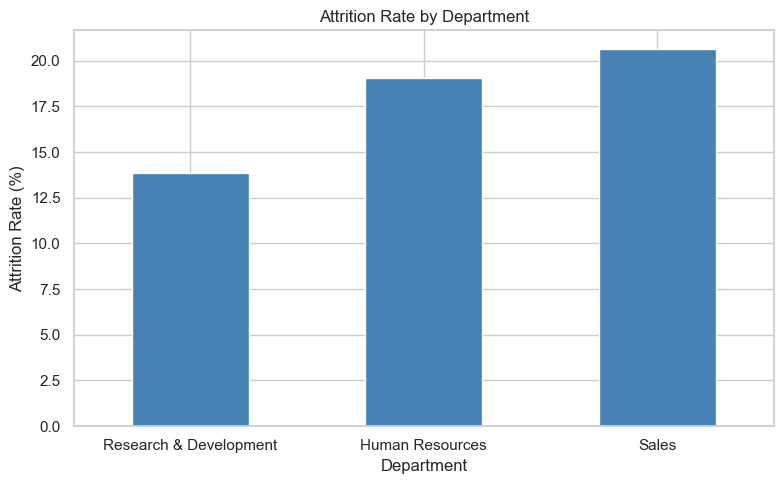

In [27]:
# Plot attrition rate by department

plt.figure(figsize=(8,5))

department_attrition[1].sort_values().plot(kind='bar', color='steelblue')

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("charts/department_attrition.png", dpi=300)

plt.show()

### Observation

The attrition rate varies across departments. The department with the highest attrition should be prioritized for employee retention programs, while departments with lower attrition may already have effective engagement practices.

In [28]:
# Calculate attrition by job role

jobrole_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
) * 100

jobrole_attrition

Attrition,0,1
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


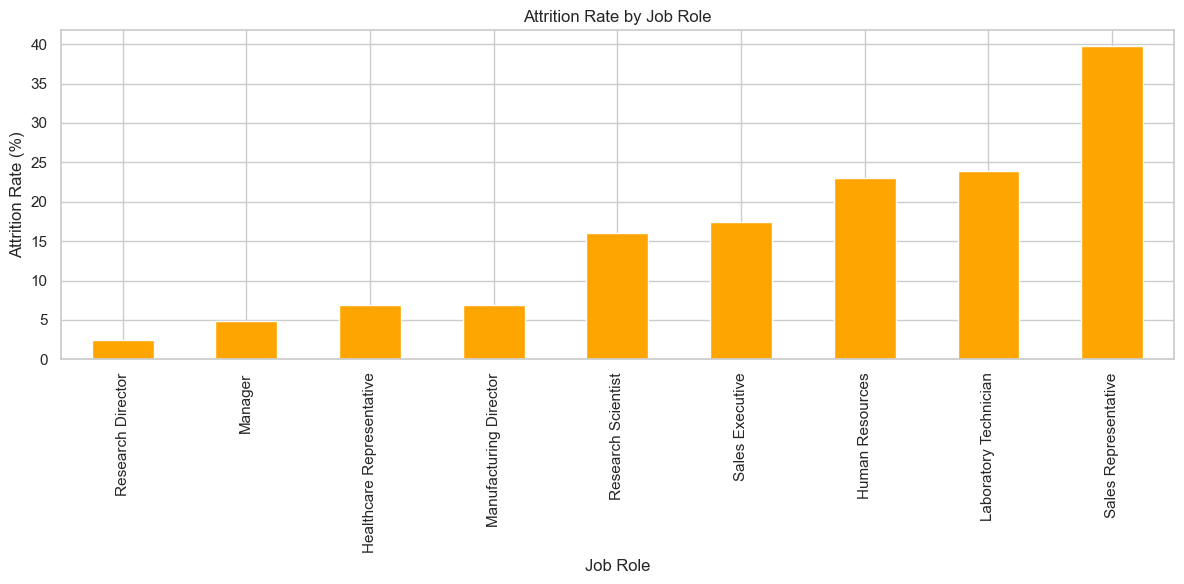

In [29]:
# Plot attrition by job role

plt.figure(figsize=(12,6))

jobrole_attrition[1].sort_values().plot(kind='bar', color='orange')

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig("charts/jobrole_attrition.png", dpi=300)

plt.show()

### Observation

Certain job roles experience noticeably higher attrition than others. HR should investigate workload, career progression, and employee satisfaction within these roles.

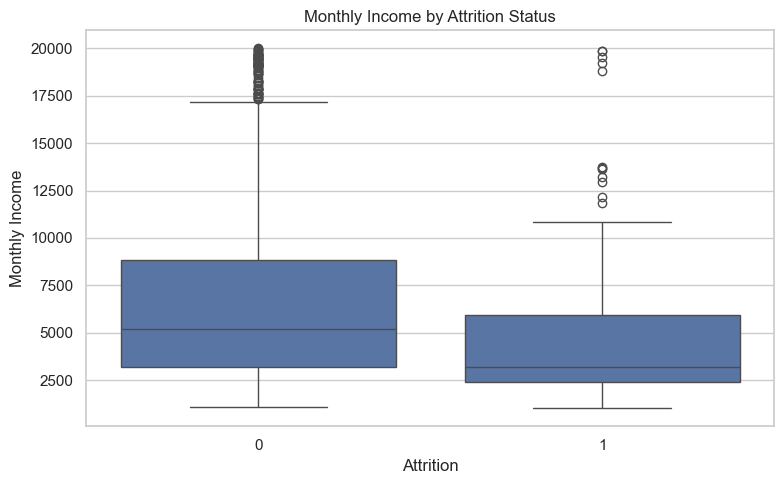

In [30]:
# Compare monthly income

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Attrition',
    y='MonthlyIncome'
)

plt.title("Monthly Income by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.tight_layout()

plt.savefig("charts/income_boxplot.png", dpi=300)

plt.show()

### Observation

Employees who left the company generally appear to have lower monthly incomes than employees who stayed. However, salary alone may not fully explain attrition.

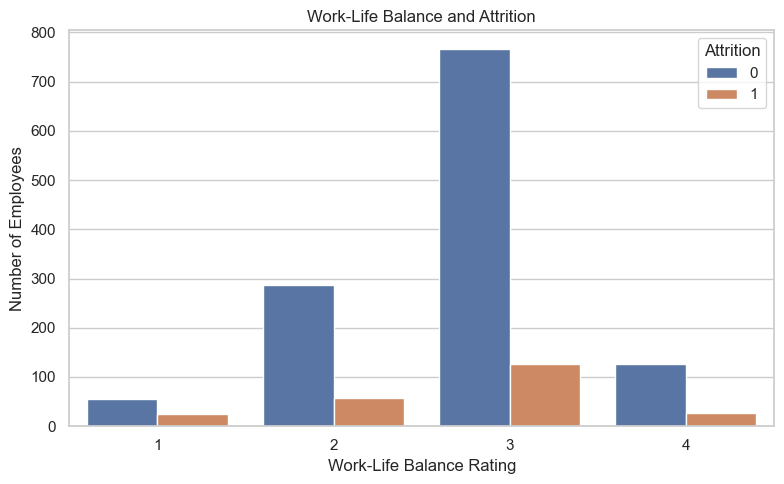

In [31]:
# Work-life balance analysis

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='WorkLifeBalance',
    hue='Attrition'
)

plt.title("Work-Life Balance and Attrition")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Number of Employees")

plt.tight_layout()

plt.savefig("charts/worklife_balance.png", dpi=300)

plt.show()

### Observation

Employees with lower work-life balance ratings tend to show higher attrition, suggesting that employee well-being plays an important role in retention.

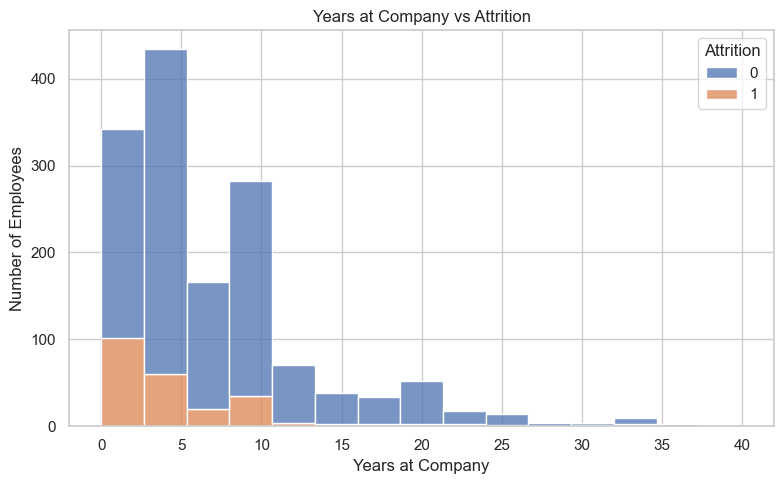

In [32]:
# Years at company analysis

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='YearsAtCompany',
    hue='Attrition',
    multiple='stack',
    bins=15
)

plt.title("Years at Company vs Attrition")
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")

plt.tight_layout()

plt.savefig("charts/years_company.png", dpi=300)

plt.show()

### Observation

Employee turnover appears to be higher during the early years of employment, indicating that new employees may require additional support and engagement.

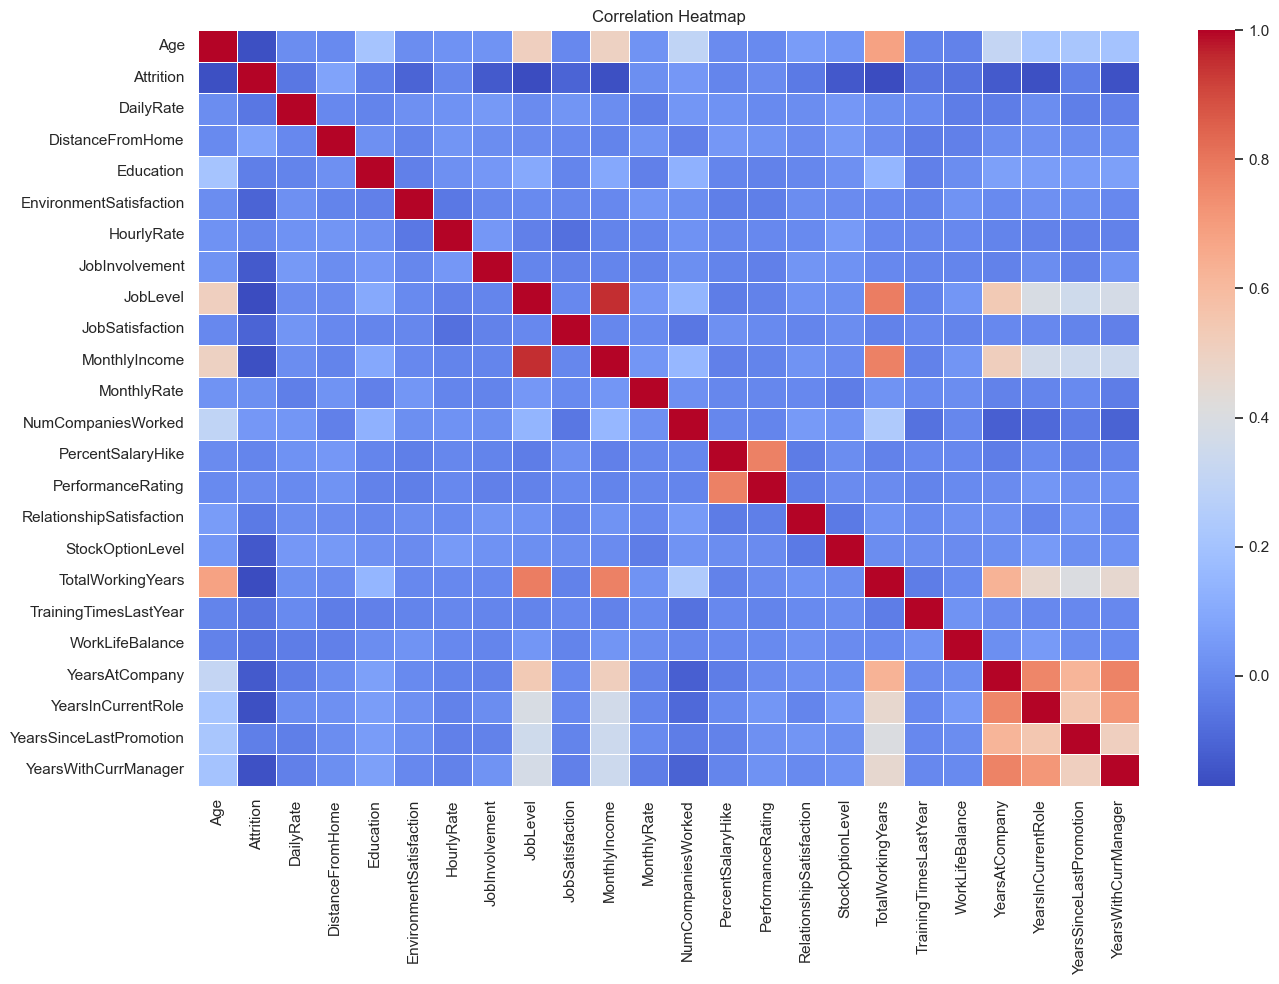

In [33]:
# Correlation heatmap

plt.figure(figsize=(14,10))

correlation = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(
    correlation,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("charts/correlation_heatmap.png", dpi=300)

plt.show()

## Business Insights

1. The **Sales** department recorded the highest attrition rate, indicating that HR should prioritize retention strategies for employees in this department.

2. Employees working as **Sales Representatives** showed the highest likelihood of leaving the company, followed by **Laboratory Technicians**, suggesting these roles may face greater work pressure or limited career growth.

3. Employees with lower monthly incomes generally exhibited higher attrition, indicating that compensation may influence employee retention. However, salary is not the only factor contributing to attrition.

4. Attrition was more common among employees with **0–5 years of service**, highlighting the importance of effective onboarding, mentoring, and early career development programs.

5. Employees with **lower Work-Life Balance ratings (especially ratings 1 and 2)** showed higher employee turnover, emphasizing the need for flexible work policies and initiatives that improve employee well-being.

# Task 4: Model Building and Comparison

In this section, three machine learning classification models are trained and compared to predict employee attrition.

The models used are:

- Logistic Regression
- Random Forest Classifier
- Gradient Boosting Classifier

The dataset is divided into training and testing sets using an 80:20 ratio. Since the dataset is imbalanced, the `class_weight='balanced'` parameter is used wherever applicable to reduce bias toward the majority class.

In [34]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (1176, 30)
Testing Set: (294, 30)


### Observation

The dataset was split into 80% training data and 20% testing data. Stratified sampling was used to preserve the original distribution of the target variable in both datasets.

## Logistic Regression

Logistic Regression is used as a baseline model because it is simple, interpretable, and effective for binary classification problems.

In [35]:
# Train Logistic Regression

logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ))
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Age','BusinessTravel','DailyRate',...,'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By

## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [36]:
# Train Random Forest

random_forest_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ))
])

random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Age','BusinessTravel','DailyRate',...,'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By

## Gradient Boosting Classifier

Gradient Boosting builds decision trees sequentially, where each new tree attempts to correct the errors made by the previous one. It often achieves strong predictive performance on structured datasets.

In [37]:
# Train Gradient Boosting

gradient_boosting_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        random_state=42
    ))
])

gradient_boosting_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Age','BusinessTravel','DailyRate',...,'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By

In [38]:
print("Logistic Regression model trained successfully.")

print("Random Forest model trained successfully.")

print("Gradient Boosting model trained successfully.")

Logistic Regression model trained successfully.
Random Forest model trained successfully.
Gradient Boosting model trained successfully.


## Summary

Three machine learning models were successfully trained using the preprocessed training data.

- Logistic Regression serves as the baseline model.
- Random Forest captures complex, non-linear relationships through an ensemble of decision trees.
- Gradient Boosting improves predictions by sequentially correcting previous errors.

These models will now be evaluated using multiple performance metrics to identify the most effective model for predicting employee attrition.

# Task 5: Model Evaluation

The trained machine learning models are evaluated using multiple performance metrics to determine their effectiveness in predicting employee attrition.

The evaluation metrics include:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix

These metrics provide a comprehensive assessment of each model's predictive performance.

In [39]:
# Make predictions using all models

logistic_pred = logistic_model.predict(X_test)
random_forest_pred = random_forest_model.predict(X_test)
gradient_boosting_pred = gradient_boosting_model.predict(X_test)

logistic_prob = logistic_model.predict_proba(X_test)[:, 1]
random_forest_prob = random_forest_model.predict_proba(X_test)[:, 1]
gradient_boosting_prob = gradient_boosting_model.predict_proba(X_test)[:, 1]

In [40]:
# Create a function to evaluate models

def evaluate_model(model_name, y_true, y_pred, y_prob):
    
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

In [41]:
# Evaluate all models

results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_pred,
        logistic_prob
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        random_forest_pred,
        random_forest_prob
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gradient_boosting_pred,
        gradient_boosting_prob
    )
)

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.round(3)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.755,0.356,0.660,0.463,0.804
1,Random Forest,0.833,0.469,0.319,0.380,0.780
2,Gradient Boosting,0.850,0.588,0.213,0.312,0.794


In [42]:
# Logistic Regression

print("Logistic Regression")
print(classification_report(y_test, logistic_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294



In [43]:
# Random Forest

print("Random Forest")
print(classification_report(y_test, random_forest_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       247
           1       0.47      0.32      0.38        47

    accuracy                           0.83       294
   macro avg       0.67      0.63      0.64       294
weighted avg       0.81      0.83      0.82       294



In [44]:
# Gradient Boosting

print("Gradient Boosting")
print(classification_report(y_test, gradient_boosting_pred))

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



In [45]:
# Find the best model based on ROC-AUC

best_model = comparison_df.loc[
    comparison_df["ROC-AUC"].idxmax()
]

best_model

Model        Logistic Regression
Accuracy                   0.755
Precision                  0.356
Recall                      0.66
F1 Score                   0.463
ROC-AUC                    0.804
Name: 0, dtype: object

### Observation

Among the three evaluated models, **Logistic Regression** achieved the highest ROC-AUC score (0.804), the highest Recall (0.660), and the highest F1-Score (0.463).

Although Gradient Boosting achieved the highest overall Accuracy (85%), it correctly identified only 21.3% of employees who left the company. Since the primary objective of this project is to identify employees at risk of attrition, Recall is a more important metric than Accuracy.

Therefore, **Logistic Regression** was selected as the best-performing model because it provides the best balance between identifying employees likely to leave and maintaining overall predictive performance.

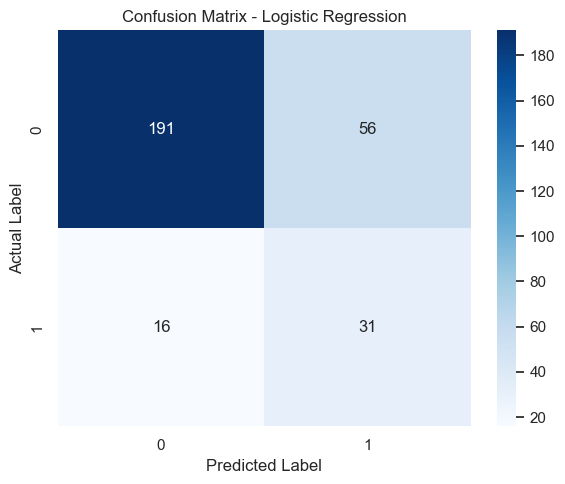

In [46]:
# Confusion Matrix

cm = confusion_matrix(y_test, logistic_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig("charts/confusion_matrix.png", dpi=300)

plt.show()

In [48]:
# Get feature names after preprocessing

feature_names = logistic_model.named_steps['preprocessor'].get_feature_names_out()

# Get coefficient values

coefficients = logistic_model.named_steps['classifier'].coef_[0]

# Create DataFrame

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Calculate absolute importance

feature_importance['Importance'] = feature_importance['Coefficient'].abs()

# Sort features

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Importance
43,cat__OverTime_Yes,1.623568,1.623568
23,cat__BusinessTravel_Travel_Frequently,1.598904,1.598904
34,cat__JobRole_Laboratory Technician,1.569722,1.569722
40,cat__JobRole_Sales Representative,1.276684,1.276684
37,cat__JobRole_Research Director,-1.117217,1.117217
30,cat__EducationField_Other,-1.027636,1.027636
24,cat__BusinessTravel_Travel_Rarely,0.906933,0.906933
42,cat__MaritalStatus_Single,0.864752,0.864752
33,cat__JobRole_Human Resources,0.645775,0.645775
16,num__TotalWorkingYears,-0.615535,0.615535


In [49]:
# Clean feature names

feature_importance['Feature'] = (
    feature_importance['Feature']
    .str.replace('cat__', '', regex=False)
    .str.replace('num__', '', regex=False)
)

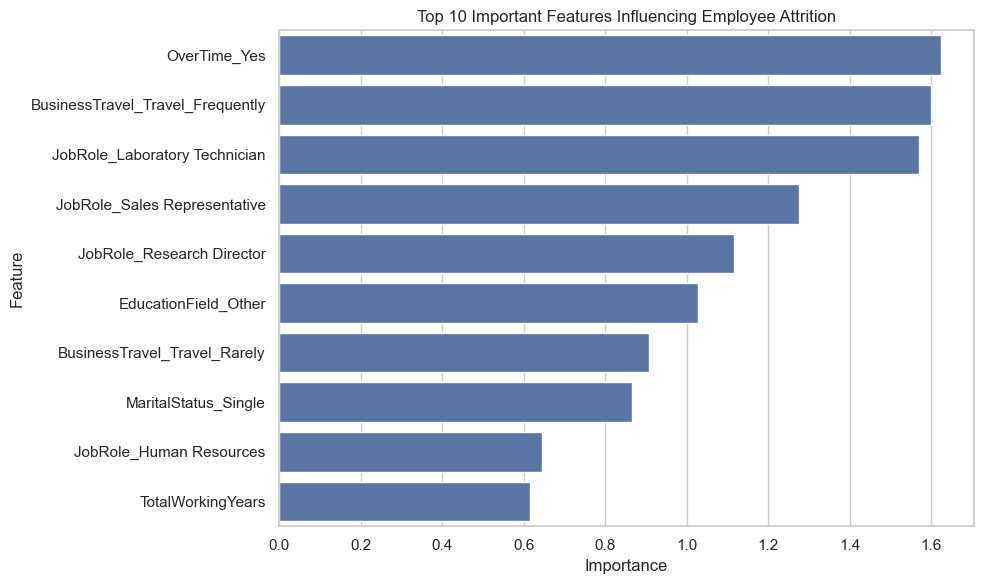

In [50]:
# Plot top 10 important features

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features Influencing Employee Attrition")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig("charts/feature_importance.png", dpi=300)

plt.show()

In [51]:
# Display features with positive and negative influence

feature_importance.sort_values(
    by='Coefficient',
    ascending=False
).head(10)

,Feature,Coefficient,Importance
43,OverTime_Yes,1.623568,1.623568
23,BusinessTravel_Travel_Frequently,1.598904,1.598904
34,JobRole_Laboratory Technician,1.569722,1.569722
40,JobRole_Sales Representative,1.276684,1.276684
24,BusinessTravel_Travel_Rarely,0.906933,0.906933
42,MaritalStatus_Single,0.864752,0.864752
33,JobRole_Human Resources,0.645775,0.645775
7,JobLevel,0.547244,0.547244
21,YearsSinceLastPromotion,0.491743,0.491743
11,NumCompaniesWorked,0.459191,0.459191


In [52]:
feature_importance.sort_values(
    by='Coefficient'
).head(10)

,Feature,Coefficient,Importance
37,JobRole_Research Director,-1.117217,1.117217
30,EducationField_Other,-1.027636,1.027636
16,TotalWorkingYears,-0.615535,0.615535
27,EducationField_Life Sciences,-0.458009,0.458009
22,YearsWithCurrManager,-0.442251,0.442251
4,EnvironmentSatisfaction,-0.413887,0.413887
29,EducationField_Medical,-0.407741,0.407741
25,Department_Research & Development,-0.405559,0.405559
8,JobSatisfaction,-0.389988,0.389988
6,JobInvolvement,-0.283774,0.283774


## Top 10 Features Influencing Employee Attrition

Based on the Logistic Regression model, the following features had the greatest influence on predicting employee attrition:

| Rank | Feature | Effect on Attrition |
|------|---------|---------------------|
| 1 | OverTime (Yes) | Strongly Increases |
| 2 | Business Travel (Travel Frequently) | Strongly Increases |
| 3 | Job Role – Laboratory Technician | Strongly Increases |
| 4 | Job Role – Sales Representative | Increases |
| 5 | Business Travel (Travel Rarely) | Moderately Increases |
| 6 | Marital Status – Single | Increases |
| 7 | Job Role – Human Resources | Increases |
| 8 | Job Level | Moderately Increases |
| 9 | Years Since Last Promotion | Increases |
| 10 | Number of Companies Worked | Increases |

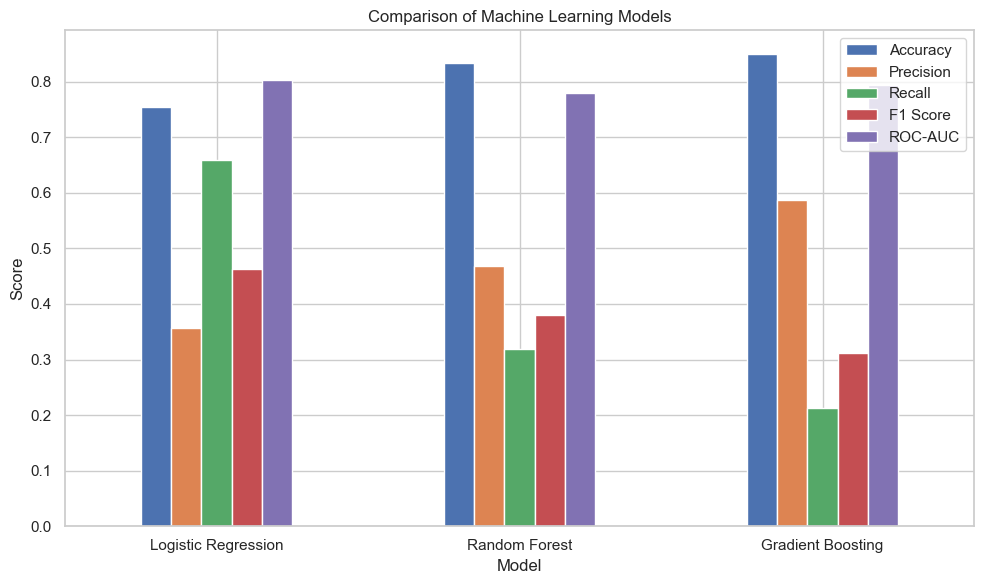

In [53]:
# Compare all metrics visually

comparison_df.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("charts/model_comparison.png", dpi=300)

plt.show()

### Interpretation

The Logistic Regression model indicates that employees who work overtime, travel frequently for business, are Laboratory Technicians or Sales Representatives, have not received recent promotions, or have worked at multiple companies are more likely to leave the organization.

On the other hand, employees working as Research Directors, those with higher total working experience, higher job satisfaction, better job involvement, and greater environment satisfaction are less likely to leave the company.

### Which three factors most strongly predict that an employee will leave?

The three strongest predictors of employee attrition identified by the Logistic Regression model are:

1. Employees who work **OverTime**.
2. Employees who **travel frequently** for business.
3. Employees working as **Laboratory Technicians**.

### Which department or job role should HR prioritize?

The analysis suggests that the **Sales Department** has the highest attrition rate. Additionally, employees working as **Sales Representatives** and **Laboratory Technicians** show a higher likelihood of leaving the company. HR should prioritize these departments and job roles for employee retention initiatives.

### Does salary alone explain attrition?

No. Although lower monthly income is associated with higher attrition, the analysis shows that other factors such as overtime, business travel, job role, years since last promotion, and work-life balance also have a significant influence on employee turnover. Therefore, salary alone does not fully explain employee attrition.

### HR Recommendations

1. Reduce excessive overtime and monitor employees who frequently travel for business. Introducing flexible work arrangements and promoting work-life balance may improve employee retention.

2. Conduct regular career development and promotion discussions for employees, especially those who have not received a promotion for several years or belong to high-risk job roles such as Sales Representatives and Laboratory Technicians.

### Limitation

This model is trained on historical HR data and cannot capture personal circumstances, organizational culture changes, future economic conditions, or individual employee motivations. Therefore, the predictions should be used to support HR decision-making rather than replace human judgment.

# Project Summary

## Executive Summary for HR Director

This project analyzed employee information to identify patterns associated with employee attrition. The objective was to understand which employees are more likely to leave the organization and provide insights that can support better workforce planning and retention strategies.

The analysis found that employees who frequently work overtime, travel regularly for business, and work in certain job roles, particularly Sales Representatives and Laboratory Technicians, are more likely to leave the company. Employees who have not received promotions for a longer period and those who have worked in multiple organizations also showed a higher risk of attrition.

While salary plays a role in employee retention, it is not the only contributing factor. Workplace conditions, career growth opportunities, work-life balance, and job responsibilities have a significant impact on an employee's decision to stay with the organization.

Based on these findings, the organization should focus on reducing excessive overtime, improving work-life balance, providing clear career progression opportunities, and conducting regular employee engagement discussions, particularly for employees in high-risk departments and job roles.

This predictive model can assist HR teams in identifying employees who may require additional support or retention efforts. However, the predictions should be used as a decision-support tool rather than a replacement for professional HR judgment, as individual circumstances cannot always be captured through historical employee data.

# Conclusion

This project successfully developed a machine learning solution to predict employee attrition using historical HR data. Three classification models were trained and compared, with Logistic Regression providing the best overall performance based on its ability to identify employees at risk of leaving.

The analysis highlighted several important factors influencing employee attrition, including overtime, frequent business travel, specific job roles, career progression, and work-life balance. These insights can help organizations take proactive measures to improve employee satisfaction, reduce turnover, and strengthen long-term workforce retention.

Overall, this project demonstrates how data-driven decision-making can support HR departments in developing effective employee retention strategies.

# Future Scope

Future improvements to this project may include:

- Using larger and more diverse HR datasets from multiple organizations.
- Applying advanced machine learning models such as XGBoost or LightGBM.
- Performing hyperparameter tuning to improve prediction performance.
- Developing an interactive dashboard for HR managers using Power BI or Streamlit.
- Deploying the trained model as a web application for real-time employee attrition prediction.